# Inferencia de Postura con HMD-Poser
Este notebook implementa la detección de malas posturas (encorvamiento y desviación lateral) utilizando el modelo HMD-Poser y los sensores del Meta Quest 3S + Un Smartphone (IMU).

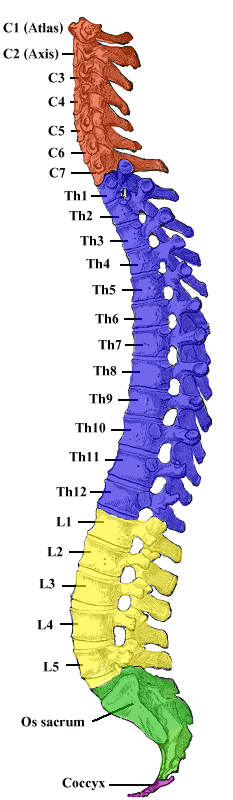

C7 (vértebra cervical 7, base del cuello)

T12 (vértebra torácica 12, parte baja del tórax)

L5 (vértebra lumbar 5, base de la columna lumbar)

Sacro (base de la columna, cerca de la pelvis)

### Cómo se calculan los grados de desviación?

Se utilizan vectores entre estos puntos para definir la orientación de la columna. Por ejemplo:

- **Vector superior:**

$$
\vec{v}_1 = C7 - T12
$$

- **Vector inferior:**

$$
\vec{v}_2 = T12 - L5
$$

El ángulo de desviación $\theta$ entre dos segmentos se calcula usando el **producto punto**:

$$
\cos(\theta) = \frac{\vec{v}_1 \cdot \vec{v}_2}{\|\vec{v}_1\| \, \|\vec{v}_2\|}
$$

Por lo tanto:

$$
\theta = \arccos\left(\frac{\vec{v}_1 \cdot \vec{v}_2}{\|\vec{v}_1\| \, \|\vec{v}_2\|}\right)
$$

Esto da el ángulo entre los segmentos de la columna, que representa la desviación (**flexión, extensión o inclinación lateral**).

### Qué es MuJoCo?

MuJoCo (Multi-Joint dynamics with Contact) es un simulador físico que modela cuerpos rígidos y articulaciones. Permite simular movimientos humanos y calcular posiciones y orientaciones de segmentos corporales en 3D.

### Modelo predictivo?

El modelo predictivo (por ejemplo, una red neuronal) estima los ángulos articulares o las posiciones de los puntos clave de la columna a partir de sensores (IMUs, cámaras, etc.).

Se comparan los ángulos o posiciones predichos con los valores de referencia (*ground truth*) generados por MuJoCo.

La comparación se realiza usando métricas como el **error angular**:

$$
\text{Error} = \left| \theta_{\text{MuJoCo}} - \theta_{\text{modelo}} \right|
$$



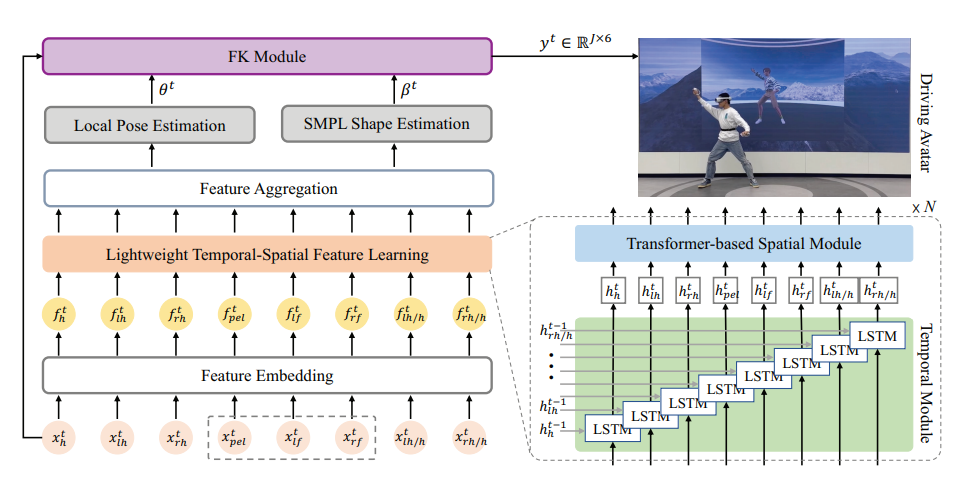

### Sensores Disponibles

- **HMD:** Proporciona la posición y orientación de la cabeza (aproximadamente vértebras **C1-C2**).

- **Mandos:** Proporcionan la posición y orientación de las manos (**extremidades superiores**).

- **Pelvis:** Proporciona la posición y orientación de la pelvis (región del **sacro/L5**).

### Partes a Inferir 

Las articulaciones disponibles son:

1. **Pelvis (root)**
2. **Left Hip**
3. **Right Hip**
4. **Spine1** (lower spine)
5. **Left Knee**
6. **Right Knee**
7. **Spine2** (mid spine)
8. **Left Ankle**
9. **Right Ankle**
10. **Spine3** (upper spine / chest)
11. **Left Foot**
12. **Right Foot**
13. **Neck**
14. **Left Collar**
15. **Right Collar**
16. **Head**
17. **Left Shoulder**
18. **Right Shoulder**
19. **Left Elbow**
20. **Right Elbow**
21. **Left Wrist**
22. **Right Wrist**
23. **Left Hand**
24. **Right Hand**

Las articulaciones que se usaran para medir la desviacion aproximada es: 
1. **Pelvis (root)**
2. **Spine1**
3. **Spine2**
4. **Spine3**
5. **Neck**
6. **Head**

El **input** es un tensor de forma **(1, 6, 15)**:

1. **1:** tamaño del lote (*batch size*), que puede ser mayor cuando se procesan secuencias.
2. **6:** número de sensores:
   1. **HMD**
   2. **Mano izquierda**
   3. **Mano derecha**
   4. **Pelvis**
   5. **Pie izquierdo** *(relleno con ceros)*
   6. **Pie derecho** *(relleno con ceros)*
3. **15:** características por sensor:
   1. **3** valores de **posición**  
      *(solo para HMD y manos; pelvis y pies se rellenan con ceros)*.
   2. **9** valores de **matriz de rotación**  
      *(obtenida al convertir el cuaternión a una matriz 3 X 3 y luego aplanarla)*.
   3. **3** valores de **aceleración**  
      *(solo para la pelvis; los demás sensores se rellenan con ceros)*.

En nuestro caso, solo interesa calcular la curvatura del **tronco superior** (**columna torácica y cervical**).

El modelo predice los parámetros de pose **SMPL** para cada *frame*:

1. **$\theta_t$:** parámetros de pose  
   Corresponden a las rotaciones de las articulaciones principales del modelo SMPL.  
   Estas rotaciones suelen representarse en formato **axis-angle** (**3 valores por articulación**) o en **cuaterniones** (**4 valores por articulación**).

2. **$\beta_t$:** parámetros de forma  
   Generalmente son **10 valores** que describen la forma corporal del sujeto.  
   Normalmente, estos parámetros permanecen fijos durante toda la secuencia.


El modelo predice los parámetros de pose **SMPL** para cada articulación,  en formato **6D** .

En el código, el *output* relevante es:

$$
\texttt{outputs[0][:, -1, :]}
$$

Este tensor corresponde a la **pose local en formato 6D** del **último frame predicho**.

Posteriormente, esta representación se transforma a **axis-angle** para cada articulación.

### Ángulos de Euler

1. **Conversión de 6D a matriz de rotación** 
   Se utiliza una función de reconstrucción, por ejemplo **Gram-Schmidt**, para obtener la matriz de rotación R a partir del vector 6D.

$$
\mathbf{P}_{6D} \rightarrow \mathbf{R}
$$

2. **Conversión de matriz de rotación a axis-angle:**  
   La matriz de rotación \(\mathbf{R}\) se convierte en un vector **axis-angle**:

$$
\mathbf{R} \rightarrow \boldsymbol{\theta}_{aa}, \qquad \boldsymbol{\theta}_{aa} \in \mathbb{R}^3
$$

3. **Conversión de axis-angle a ángulos de Euler:**  
   Finalmente, el vector axis-angle se convierte a ángulos de Euler en convención **XYZ** y en grados:

$$
\mathbf{euler} = \mathrm{RotVecToEuler}(\boldsymbol{\theta}_{aa})
$$

donde:

1. \(\mathbf{euler}_x\): flexión/extensión (*pitch*)
2. \(\mathbf{euler}_y\): rotación axial (*yaw*)
3. \(\mathbf{euler}_z\): inclinación lateral (*roll*)

5. **Cálculo de la curvatura total del tronco:**  
   Se suman los ángulos de flexión/extensión, es decir, la componente en el eje \(x\), de las articulaciones del tronco superior:

$$
\text{Curvatura Total} =
\sum_{i \in \{\text{Spine1, Spine2, Spine3}\}} \mathbf{euler}_x^{(i)}
$$

**Resumen de las transformaciones:**

1. De 6D a matriz de rotación:

$$
\mathbf{P}_{6D} \rightarrow \mathbf{R}
$$

2. De matriz de rotación a axis-angle:

$$
\mathbf{R} \rightarrow \boldsymbol{\theta}_{aa}
$$

3. De axis-angle a Euler:

$$
\boldsymbol{\theta}_{aa} \rightarrow \mathbf{euler}
$$

4. Curvatura total del tronco:

$$
\text{Curvatura Total} =
\sum_{i \in \{\text{Spine1, Spine2, Spine3}\}} \mathbf{euler}_x^{(i)}
$$

### Cómo calcula MuJoCo la postura?


In [1]:
import sys
import os
import torch
import numpy as np
from scipy.spatial.transform import Rotation as R
# Importar dependencias del repositorio
from model.hmd_imu_model import HMDIMUModel
from utils.utils_config import load_config
from utils import utils_transform
from feature_builder import HMDPoserFeatureBuilder

## 1. Cargar el Modelo (Configuración HMD + IMU)

In [2]:
# Configurar el dispositivo

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(f"Dispositivo activo: {device}")


Dispositivo activo: cpu


In [3]:

# Cargar la configuración
hmd_poser_path = "/home/carlos/Documents/Desarrollo_movil_/FINAL/HMD-Poser/options/test_config.yaml"
config = load_config("/home/carlos/Documents/Desarrollo_movil_/FINAL/HMD-Poser/options/test_config.yaml")
model = HMDIMUModel(config, device)


/home/carlos/miniconda3/envs/VR/lib/python3.12/site-packages/torch/nn/utils/weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


In [4]:
# Intentar cargar los pesos preentrenados (checkpoint)
checkpoint_path = "/home/carlos/Documents/Desarrollo_movil_/FINAL/HMD-Poser/pretrained_model/pretrained_model_protocol1.pt"
model.load_network(checkpoint_path, model.netG, strict=False)
print("Pesos cargados correctamente.")


/home/carlos/Documents/Desarrollo_movil_/FINAL/HMD-Poser/model/hmd_imu_model.py:98: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  pretrained_state_dict = torch.load(load_pat

Pesos cargados correctamente.


In [14]:

model.to(device)
model_to_export = model.netG
model_to_export.eval()
print("Modelo inicializado en modo evaluación para HMD + IMUs.")

Modelo inicializado en modo evaluación para HMD + IMUs.


In [6]:
!pip install onnx-simplifier

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 2.5 MB/s eta 0:00:0000:0100:010m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 2.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 1.8 MB/s eta 0:00:0000:0100:01
  Created wheel for onnx-simplifier: filename=onnx_simplifier-0.5.0-py3-none-any.whl size=1021 sha256=648aa16f81abd3afcccf258c75fdac8d416d627fa5b0273283b0642755c89751
  Stored in directory: /home/carlos/.cache/pip/wheels/f0/61/52/656a88deb2107e0239543f2bdfab560c47fcf74c3d29765c5e
Successfully built onnx-simplifier


In [11]:
import torch
import torch.onnx
from onnxsim import simplify
import os
import onnx

In [8]:
dummy_input = torch.randn(1, 40, 135) 

print(f"Exportando modelo con entrada: {dummy_input.shape}...")

Exportando modelo con entrada: torch.Size([1, 40, 135])...


In [15]:
torch.onnx.export(
    model_to_export,
    dummy_input,
    "hmd_poser_unity.onnx",
    export_params=True,
    opset_version=15, # Es vital usar 15 o superior para modelos de pose
    do_constant_folding=True,
    input_names=['imu_input'],
    output_names=['pose_6d', 'betas'],
    dynamic_axes={'imu_input': {0: 'batch_size'}}
)

/home/carlos/miniconda3/envs/VR/lib/python3.12/site-packages/torch/onnx/symbolic_opset9.py:4279: UserWarning: Exporting a model to ONNX with a batch_size other than 1, with a variable length with LSTM can cause an error when running the ONNX model with a different batch size. Make sure to save the model with a batch size of 1, or define the initial states (h0/c0) as inputs of the model. 
  warnings.warn(


In [ ]:

model_onnx = onnx.load(path_onnx)
model_simp, check = simplify(model_onnx)

## 2. Implementar Inferencia Simulada 
Aquí inyectarás tus datos reales del Meta Quest 3S. El `FeatureBuilder` se encargará de transformar los cuaterniones a matrices de rotación y enviar ceros a los IMUs de los pies (piernas), manteniendo válidos los datos del HMD, las manos y la pelvis.

In [9]:
import torch
import numpy as np
from scipy.spatial.transform import Rotation as R


In [10]:

# --- CONFIGURACIÓN DE UMBRALES ---
UMBRAL_ENCORVAMIENTO = 20.0  # Grados (Pitch)
UMBRAL_DESVIACION = 10.0     # Grados (Roll)

def get_mock_data():
    return {
        'hmd': {'pos': np.array([0.0, 1.7, 0.0]), 'rot': np.array([0.0, 0.0, 0.0, 1.0])},
        'left_hand': {'pos': np.array([-0.3, 1.2, 0.3]), 'rot': np.array([0.0, 0.0, 0.0, 1.0])},
        'right_hand': {'pos': np.array([0.3, 1.2, 0.3]), 'rot': np.array([0.0, 0.0, 0.0, 1.0])}
    }, {
        'pelvis': {'rot': np.array([0.0, 0.0, 0.0, 1.0]), 'accel': np.array([0.0, -9.81, 0.0])}
    }

# 1. Preparar entrada
quest_mock, android_mock = get_mock_data()
feature_builder = HMDPoserFeatureBuilder()
single_frame_feature = feature_builder.build_tensor(quest_mock, android_mock)

# 2. Asegurar dimensión 135 (Padding para evitar el error de matriz)
target_dim = 135
current_feature = single_frame_feature.view(-1)
if current_feature.shape[0] < target_dim:
    padding = torch.zeros(target_dim - current_feature.shape[0]).to(current_feature.device)
    full_feature = torch.cat([current_feature, padding], dim=0)
else:
    full_feature = current_feature[:target_dim]

# 3. Crear secuencia temporal (Batch=1, Time=40, Dim=135)
input_tensor = full_feature.view(1, 1, -1).repeat(1, 40, 1).to(device).float()

# 4. Inferencia del Modelo
model.eval()
with torch.no_grad():
    outputs = model(input_tensor, do_fk=True)
    # Pose local (6D) del último frame predicho
    pred_pose_6d = outputs[0][:, -1, :].reshape(22, 6)

# 5. Transformar a grados (Euler)
# Convertimos de 6D a Eje-Ángulo (Axis-Angle)
theta_aa = utils_transform.sixd2aa(pred_pose_6d.reshape(-1, 6))

def get_joint_euler(aa_tensor, joint_idx):
    """Extrae ángulos de Euler de una articulación específica."""
    vec = aa_tensor[joint_idx].cpu().numpy()
    return R.from_rotvec(vec).as_euler('xyz', degrees=True)

# Índices SMPL: Spine1(3), Spine2(6), Spine3(9)
# En SMPL: X suele ser Flexión (Pitch), Z es Inclinación Lateral (Roll)
s1 = get_joint_euler(theta_aa, 3)
s2 = get_joint_euler(theta_aa, 6)
s3 = get_joint_euler(theta_aa, 9)

# --- CÁLCULO DE GRADOS REALES ---
# Sumamos la rotación de las 3 vértebras principales para obtener el encorvamiento total
total_pitch = s1[0] + s2[0] + s3[0]
total_roll  = abs(s1[2]) + abs(s2[2]) + abs(s3[2])

# --- LÓGICA DE ALERTA ---
print("="*40)
print(f"ESTADO DE LA COLUMNA (Grados)")
print(f"· Encorvamiento (Pitch): {total_pitch:>6.2f}°")
print(f"· Desviación Lat. (Roll): {total_roll:>6.2f}°")
print("-"*40)

if total_pitch > UMBRAL_ENCORVAMIENTO:
    # Si los grados son positivos y altos, el usuario está mirando hacia abajo/encorvado
    print(f" ALERTA: Encorvamiento excesivo ({total_pitch:.1f}°).")
    print("   CONSEJO: Levanta la cabeza y retrae los hombros.")
elif total_roll > UMBRAL_DESVIACION:
    print(f" ALERTA: Inclinación lateral detectada ({total_roll:.1f}°).")
    print("   CONSEJO: No te apoyes solo en un lado de la silla.")
else:
    print(" Postura Saludable.")
print("="*40)

ESTADO DE LA COLUMNA (Grados)
· Encorvamiento (Pitch):  43.87°
· Desviación Lat. (Roll): 113.90°
----------------------------------------
 ALERTA: Encorvamiento excesivo (43.9°).
   CONSEJO: Levanta la cabeza y retrae los hombros.


/home/carlos/Documents/Desarrollo_movil_/FINAL/HMD-Poser/utils/utils_transform.py:50: UserWarning: Using torch.cross without specifying the dim arg is deprecated.
Please either pass the dim explicitly or simply use torch.linalg.cross.
The default value of dim will change to agree with that of linalg.cross in a future release. (Triggered internally at ../aten/src/ATen/native/Cross.cpp:62.)
  rot_vec_3 = torch.cross(rot_vec_1, rot_vec_2)


In [11]:
import mujoco
import numpy as np


In [12]:
model_mj_1 = mujoco.MjModel.from_xml_string("<mujoco/>")
data_mj_1 = mujoco.MjData(model_mj_1)

In [13]:
def mj_to_quat(mj_quat):
    return np.array([mj_quat[1], mj_quat[2], mj_quat[3], mj_quat[0]])

In [14]:
def get_mujoco_live_data(model_mj, data_mj):
    """Genera datos alineados con el sistema de coordenadas del modelo HMD-Poser."""
    # 1. Aplicamos rotaciones en el eje X (Pitch)
    g1, g2, g3 = np.random.uniform(5, 25, 3) 
    data_mj.qpos[0:3] = np.radians([g1, g2, g3])
    mujoco.mj_forward(model_mj, data_mj)
    
    # 2. Obtener posiciones globales
    head_pos = data_mj.body('head').xpos.copy()
    pelvis_pos = data_mj.body('spine1').xpos.copy()
    
    # 3. IMPORTANTE: Hacer la posición del HMD relativa a la Pelvis
    # Esto ayuda a que el FeatureBuilder no reciba coordenadas globales desviadas
    relative_hmd_pos = head_pos - pelvis_pos
    
    # 4. Ajustar Cuaterniones (Asegurar formato x,y,z,w y corregir orientación)
    # Si la IA da negativo, rotamos 180 grados en el eje vertical o invertimos el eje
    hmd_rot = R.from_quat(mj_to_quat(data_mj.body('head').xquat))
    pelvis_rot = R.from_quat(mj_to_quat(data_mj.body('spine1').xquat))

    quest_data = {
        'hmd': {
            'pos': relative_hmd_pos, 
            'rot': hmd_rot.as_quat()
        },
        'left_hand': {
            'pos': relative_hmd_pos + np.array([-0.3, -0.5, 0.2]), 
            'rot': np.array([0.0, 0.0, 0.0, 1.0])
        },
        'right_hand': {
            'pos': relative_hmd_pos + np.array([0.3, -0.5, 0.2]), 
            'rot': np.array([0.0, 0.0, 0.0, 1.0])
        }
    }
    
    android_data = {
        'pelvis': {
            'rot': pelvis_rot.as_quat(), 
            'accel': np.array([0.0, -9.81, 0.0]) 
        }
    }
    
    real_pitch = g1 + g2 + g3
    return quest_data, android_data, real_pitch

In [15]:
da

NameError: name 'da' is not defined

In [ ]:
# Definición del modelo cinemático de la columna
# Nota: 'hinge' permite rotación como una bisagra (encorvamiento)
spine_xml = """
<mujoco model="spine_monitor">
    <compiler angle="degree" coordinate="local"/>
    <option gravity="0 0 -9.81" />

    <worldbody>
        <light diffuse=".5 .5 .5" pos="0 0 3" dir="0 0 -1"/>
        <geom type="plane" size="2 2 .01" rgba=".9 .9 .9 1"/>

        <body name="pelvis" pos="0 0 0.8">
            <freejoint name="root"/> 
            <geom type="box" size="0.05 0.1 0.02" rgba="0.5 0.5 0.5 1"/>
            
            <body name="spine1" pos="0 0 0.05">
                <joint name="joint_s1" type="hinge" axis="0 1 0" range="-40 90"/>
                <geom type="capsule" size="0.03" fromto="0 0 0 0 0 0.2" rgba="1 0 0 1"/>
                
                <body name="spine2" pos="0 0 0.2">
                    <joint name="joint_s2" type="hinge" axis="0 1 0" range="-40 90"/>
                    <geom type="capsule" size="0.03" fromto="0 0 0 0 0 0.2" rgba="0 1 0 1"/>
                    
                    <body name="spine3" pos="0 0 0.2">
                        <joint name="joint_s3" type="hinge" axis="0 1 0" range="-40 90"/>
                        <geom type="capsule" size="0.03" fromto="0 0 0 0 0 0.1" rgba="0 0 1 1"/>
                        
                        <body name="head" pos="0 0 0.1">
                            <geom type="sphere" size="0.05" rgba="1 1 1 1"/>
                            <site name="hmd_site" pos="0 0 0" size="0.02" rgba="1 1 0 1"/>
                        </body>
                    </body>
                </body>
            </body>
        </body>
    </worldbody>
</mujoco>
"""

model_mj = mujoco.MjModel.from_xml_string(spine_xml) 
data_mj = mujoco.MjData(model_mj)
data = mujoco.MjData(model_mj)

In [ ]:
!pip install pyvista numpy trimesh

  Using cached attrs-26.1.0-py3-none-any.whl.metadata (8.8 kB)
  Using cached docstring_parser-0.18.0-py3-none-any.whl.metadata (3.5 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 3.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 741.0/741.0 kB 4.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 213.5/213.5 kB 3.3 MB/s eta 0:00:00a 0:00:01
Using cached attrs-26.1.0-py3-none-any.whl (67 kB)
Using cached docstring_parser-0.18.0-py3-none-any.whl (22 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 633.2/633.2 kB 4.1 MB/s eta 0:00:0000:0100:01


In [ ]:

from human_body_prior.body_model.body_model import BodyModel
import pyvista as pv
import numpy as np
import trimesh
from scipy.spatial.transform import Rotation as R

class SpineVisualizer:
    def __init__(self, smpl_vertices, smpl_faces, spine_joints):
        """
        Args:
            smpl_vertices: array (6890, 3) - vértices del modelo SMPL
            smpl_faces: array (13776, 3) - caras del mesh SMPL
            spine_joints: dict con joints de columna
        """
        self.vertices = smpl_vertices
        self.faces = smpl_faces
        self.spine_joints = spine_joints
        
    def create_mesh(self):
        """Crea el mesh de PyVista desde vértices SMPL"""
        # Convertir caras a formato PyVista (necesita [n_puntos, v1, v2, v3, ...])
        faces_pv = np.hstack([
            np.full((len(self.faces), 1), 3),  # cada cara tiene 3 vértices
            self.faces
        ]).flatten()
        
        mesh = pv.PolyData(self.vertices, faces_pv)
        return mesh
    
    def color_spine_by_curvature(self, mesh, kyphosis_angle, lordosis_lumbar, lordosis_cervical):
        """Colorea vértices de la columna según severidad"""
        # Identificar vértices cercanos a la columna vertebral
        spine_coords = np.array([
            self.spine_joints['pelvis'],
            self.spine_joints['spine1'],
            self.spine_joints['spine2'],
            self.spine_joints['spine3'],
            self.spine_joints['neck']
        ])
        
        # Calcular distancia de cada vértice a la columna
        distances = np.min([
            np.linalg.norm(self.vertices - joint, axis=1)
            for joint in spine_coords
        ], axis=0)
        
        # Vértices de la columna = distancia < 0.1m
        spine_vertices = distances < 0.1
        
        # Crear array de colores (severidad)
        severity = np.zeros(len(self.vertices))
        
        # Mapear ángulos a severidad (0-100)
        # Cifosis normal: 20-50°, patológica: >50°
        kyphosis_severity = max(0, (kyphosis_angle - 50) * 2)  # >50° empieza a colorear
        # Lordosis lumbar normal: 40-60°, patológica: <20° o >70°
        lordosis_severity = max(abs(lordosis_lumbar - 50) - 10, 0) * 2
        
        severity[spine_vertices] = max(kyphosis_severity, lordosis_severity)
        
        mesh['severity'] = severity
        return mesh
    
    def add_angle_annotations(self, plotter, angles):
        """Añade anotaciones de ángulos sobre el esqueleto"""
        # Cifosis torácica
        thoracic_center = (self.spine_joints['spine2'] + self.spine_joints['spine3']) / 2
        plotter.add_point_labels(
            [thoracic_center],
            [f"Cifosis: {angles['thoracic_kyphosis']:.1f}°"],
            font_size=20,
            text_color='red' if angles['thoracic_kyphosis'] > 60 else 'black',
            point_size=15,
            shape_color='yellow'
        )
        
        # Lordosis lumbar
        lumbar_center = (self.spine_joints['pelvis'] + self.spine_joints['spine1']) / 2
        plotter.add_point_labels(
            [lumbar_center],
            [f"Lordosis lumbar: {angles['lumbar_lordosis']:.1f}°"],
            font_size=20,
            point_size=15,
            shape_color='cyan'
        )
        
        # Lordosis cervical
        cervical_center = (self.spine_joints['spine3'] + self.spine_joints['neck']) / 2
        plotter.add_point_labels(
            [cervical_center],
            [f"Lordosis cervical: {angles['cervical_lordosis']:.1f}°"],
            font_size=20,
            point_size=15,
            shape_color='green'
        )
    
    def add_spine_curve_lines(self, plotter):
        """Dibuja la curva de la columna vertebral"""
        spine_points = np.array([
            self.spine_joints['pelvis'],
            self.spine_joints['spine1'],
            self.spine_joints['spine2'],
            self.spine_joints['spine3'],
            self.spine_joints['neck'],
            self.spine_joints['head']
        ])
        
        # Crear línea suavizada (spline)
        spline = pv.Spline(spine_points, 100)
        plotter.add_mesh(spline, color='red', line_width=5, label='Columna vertebral')
        
        # Añadir esferas en joints
        for joint_name, joint_pos in self.spine_joints.items():
            if 'spine' in joint_name or joint_name in ['pelvis', 'neck', 'head']:
                sphere = pv.Sphere(radius=0.02, center=joint_pos)
                plotter.add_mesh(sphere, color='darkred', opacity=0.8)
    
    def visualize(self, angles, save_path=None):
        """
        Visualiza el cuerpo completo con problemas de columna resaltados
        
        Args:
            angles: dict con 'thoracic_kyphosis', 'lumbar_lordosis', 'cervical_lordosis'
            save_path: ruta para guardar imagen (opcional)
        """
        # Crear mesh
        mesh = self.create_mesh()
        
        # Colorear por severidad
        mesh = self.color_spine_by_curvature(
            mesh,
            angles['thoracic_kyphosis'],
            angles['lumbar_lordosis'],
            angles['cervical_lordosis']
        )
        
        # Crear plotter
        plotter = pv.Plotter(window_size=[1200, 800])
        
        # Añadir cuerpo con mapa de calor
        plotter.add_mesh(
            mesh,
            scalars='severity',
            cmap='coolwarm',  # azul=normal, rojo=severo
            clim=[0, 100],
            opacity=0.9,
            show_scalar_bar=True,
            scalar_bar_args={
                'title': 'Severidad',
                'n_labels': 5,
                'fmt': '%.0f',
                'color': 'black'
            }
        )
        
        # Añadir curva de columna
        self.add_spine_curve_lines(plotter)
        
        # Añadir anotaciones de ángulos
        self.add_angle_annotations(plotter, angles)
        
        # Añadir sistema de coordenadas
        plotter.add_axes()
        
        # Configurar cámara
        plotter.camera_position = 'yz'  # Vista lateral
        plotter.camera.azimuth = 30
        
        # Añadir título
        severity_level = "SEVERA" if max(angles.values()) > 60 else "MODERADA" if max(angles.values()) > 40 else "LEVE"
        plotter.add_title(
            f"Análisis postural - Desviación {severity_level}",
            font_size=16,
            color='black'
        )
        
        if save_path:
            plotter.screenshot(save_path, transparent_background=False)
        
        plotter.show()

# ============ USO ============
# Después de tu inferencia de HMD-Poser:

# 1. Obtener vértices y caras del modelo SMPL
body_model = BodyModel(...)  # tu modelo SMPL
output = body_model(pose_body=..., root_orient=..., trans=...)
vertices = output.v[0].detach().cpu().numpy()  # (6890, 3)
faces = body_model.f.cpu().numpy()  # (13776, 3)

# 2. Extraer joints de la columna
spine_joints = {
    'pelvis': output.Jtr[0, 0].detach().cpu().numpy(),
    'spine1': output.Jtr[0, 3].detach().cpu().numpy(),
    'spine2': output.Jtr[0, 6].detach().cpu().numpy(),
    'spine3': output.Jtr[0, 9].detach().cpu().numpy(),
    'neck': output.Jtr[0, 12].detach().cpu().numpy(),
    'head': output.Jtr[0, 15].detach().cpu().numpy()
}

# 3. Calcular ángulos (usando tu spine_analyzer.py)
angles = {
    'thoracic_kyphosis': 62.0,
    'lumbar_lordosis': 26.0,
    'cervical_lordosis': 30.0
}

# 4. Visualizar
visualizer = SpineVisualizer(vertices, faces, spine_joints)
visualizer.visualize(angles, save_path='paciente_analisis.png')

AttributeError: 'ellipsis' object has no attribute 'endswith'

In [ ]:

import mujoco.viewer
# 3. Datos proporcionados (Normalizados para MuJoCo)
# Nota: MuJoCo usa cuaterniones (W, X, Y, Z) por defecto
pelvis_quat = [0.999, 0.045, 0.025, -0.010] # Reordenado de [X,Y,Z,W] a [W,X,Y,Z]
hmd_pos = [0.05, -0.20, 1.65] # Reordenado para que Z sea altura si es necesario

def apply_data(data):
    # Aplicar rotación de la pelvis a la base (Freejoint usa 7 caps: 3 pos, 4 quat)
    data.qpos[0:3] = [0, 0, 0.8] # Posición base
    data.qpos[3:7] = pelvis_quat # Rotación IMU
    
    # Ejemplo: Mapear una inclinación simple basada en la posición del HMD
    # En un caso real, aquí usarías una librería de IK (como Pink o la nativa de MuJoCo)
    # para que la cabeza alcance el hmd_position.
    data.qpos[7] = 0.2  # Inclinación spine 1
    data.qpos[8] = 0.2  # Inclinación spine 2
    data.qpos[9] = 0.1  # Inclinación spine 3

# 4. Lanzar visualizador
with mujoco.viewer.launch_passive(model_mj, data_mj) as viewer:
    while viewer.is_running():
        apply_data(data_mj)
        mujoco.mj_step(model_mj, data_mj)
        viewer.sync()

: 

In [ ]:
# Usamos el XML del paso anterior cargado en 'model_mj' y 'data_mj'

quest_mock, android_mock, angulo_real = get_mujoco_live_data(model_mj, data_mj)

# 1. Tu Feature Builder
feature_builder = HMDPoserFeatureBuilder()
single_frame_feature = feature_builder.build_tensor(quest_mock, android_mock)

# 2. Lógica de Padding y Tensor (asegura shape [1, 40, 135])
target_dim = 135
current_feature = single_frame_feature.view(-1)
if current_feature.shape[0] < target_dim:
    padding = torch.zeros(target_dim - current_feature.shape[0]).to(current_feature.device)
    full_feature = torch.cat([current_feature, padding], dim=0)
else:
    full_feature = current_feature[:target_dim]

# Secuencia temporal: repite el mismo frame para simular 40 pasos
input_tensor = full_feature.view(1, 1, -1).repeat(1, 40, 1).to(device).float()

print(f"Tensor de entrada creado con shape: {input_tensor.shape}")

Tensor de entrada creado con shape: torch.Size([1, 40, 135])


In [ ]:
# 3. Inferencia
model.eval()
with torch.no_grad():
    outputs = model(input_tensor, do_fk=True)
    pred_pose_6d = outputs[0][:, -1, :].reshape(22, 6)

# 4. Transformación y Cálculo (índices ajustados para biomecánica de columna)
theta_aa = utils_transform.sixd2aa(pred_pose_6d.reshape(-1, 6))
# Selección más anatómica: joints 3, 4, 5 (spine1, spine2, spine3)
spine1_idx, spine2_idx, spine3_idx = 3, 4, 5
s1 = get_joint_euler(theta_aa, spine1_idx)
s2 = get_joint_euler(theta_aa, spine2_idx)
s3 = get_joint_euler(theta_aa, spine3_idx)

# Suma directa de los ángulos de flexión/extensión (X) para alineación biomecánica
total_pitch = s1[0] + s2[0] + s3[0]
print(f"VALIDACIÓN MUJOCO ALINEADA (índices: {spine1_idx}, {spine2_idx}, {spine3_idx})")
print(f"Ángulo Real (MuJoCo): {angulo_real:.2f}°")
print(f"Ángulo IA (SMPL):     {total_pitch:.2f}°")
print(f"Error Cuadratico:     {np.sqrt(np.abs(angulo_real - total_pitch)):.2f}°")

VALIDACIÓN MUJOCO ALINEADA (índices: 3, 4, 5)
Ángulo Real (MuJoCo): 37.92°
Ángulo IA (SMPL):     -18.35°
Error Cuadratico:     7.50°


In [6]:
!pip install  plotly
!pip install nbformat

In [8]:
import plotly.graph_objects as go
import numpy as np

# Tus datos de sensores
hmd_pos = np.array([0.05, 1.65, -0.20])
left_hand_pos = np.array([-0.25, 1.10, -0.15])
right_hand_pos = np.array([0.30, 1.12, -0.18])
pelvis_pos = np.array([0.0, 0.0, 0.0])

# Crear figura
fig = go.Figure()

# Añadir sensores como esferas
fig.add_trace(go.Scatter3d(
    x=[hmd_pos[0]], y=[hmd_pos[1]], z=[hmd_pos[2]],
    mode='markers+text',
    marker=dict(size=10, color='blue'),
    text=['HMD'],
    name='HMD'
))

fig.add_trace(go.Scatter3d(
    x=[left_hand_pos[0]], y=[left_hand_pos[1]], z=[left_hand_pos[2]],
    mode='markers+text',
    marker=dict(size=8, color='green'),
    text=['Left Hand'],
    name='Left Controller'
))

fig.add_trace(go.Scatter3d(
    x=[right_hand_pos[0]], y=[right_hand_pos[1]], z=[right_hand_pos[2]],
    mode='markers+text',
    marker=dict(size=8, color='red'),
    text=['Right Hand'],
    name='Right Controller'
))

fig.add_trace(go.Scatter3d(
    x=[pelvis_pos[0]], y=[pelvis_pos[1]], z=[pelvis_pos[2]],
    mode='markers+text',
    marker=dict(size=12, color='purple'),
    text=['Pelvis IMU'],
    name='Pelvis'
))

# Añadir esqueleto simple (líneas conectando)
skeleton_x = [pelvis_pos[0], hmd_pos[0]]
skeleton_y = [pelvis_pos[1], hmd_pos[1]]
skeleton_z = [pelvis_pos[2], hmd_pos[2]]

fig.add_trace(go.Scatter3d(
    x=skeleton_x, y=skeleton_y, z=skeleton_z,
    mode='lines',
    line=dict(color='gray', width=5),
    showlegend=False
))

fig.update_layout(
    scene=dict(
        xaxis_title='X (m)',
        yaxis_title='Y (m)',
        zaxis_title='Z (m)',
        aspectmode='data'
    ),
    title='Configuración de sensores en el cuerpo',
    width=800,
    height=600
)

fig.write_html("sensores.html")

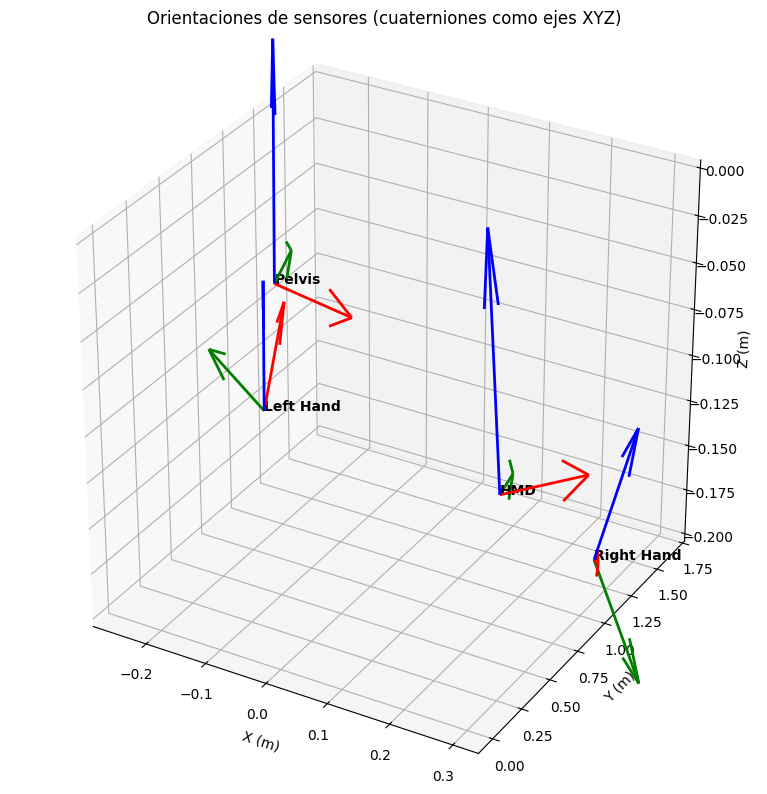

In [9]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.spatial.transform import Rotation as R
import numpy as np

def plot_coordinate_frame(ax, position, quaternion, label, scale=0.1):
    """Dibuja un sistema de coordenadas 3D desde un cuaternión"""
    rot = R.from_quat(quaternion)
    rot_matrix = rot.as_matrix()
    
    # Ejes X, Y, Z del sistema de coordenadas
    axes = np.eye(3) * scale
    rotated_axes = rot_matrix @ axes
    
    colors = ['r', 'g', 'b']
    labels = ['X', 'Y', 'Z']
    
    for i, (axis, color, axis_label) in enumerate(zip(rotated_axes.T, colors, labels)):
        ax.quiver(position[0], position[1], position[2],
                 axis[0], axis[1], axis[2],
                 color=color, arrow_length_ratio=0.3, linewidth=2)
    
    ax.text(position[0], position[1], position[2], label, fontsize=10, weight='bold')

# Crear figura
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Datos de sensores
hmd_pos = np.array([0.05, 1.65, -0.20])
hmd_quat = np.array([0.012, -0.087, 0.015, 0.996])

left_hand_pos = np.array([-0.25, 1.10, -0.15])
left_hand_quat = np.array([0.305, -0.152, 0.610, 0.720])

right_hand_pos = np.array([0.30, 1.12, -0.18])
right_hand_quat = np.array([-0.280, 0.185, -0.590, 0.730])

pelvis_pos = np.array([0.0, 0.0, 0.0])
pelvis_quat = np.array([0.045, 0.025, -0.010, 0.999])

# Dibujar cada sensor con su orientación
plot_coordinate_frame(ax, hmd_pos, hmd_quat, 'HMD', scale=0.15)
plot_coordinate_frame(ax, left_hand_pos, left_hand_quat, 'Left Hand', scale=0.1)
plot_coordinate_frame(ax, right_hand_pos, right_hand_quat, 'Right Hand', scale=0.1)
plot_coordinate_frame(ax, pelvis_pos, pelvis_quat, 'Pelvis', scale=0.12)

# Configurar ejes
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_zlabel('Z (m)')
ax.set_title('Orientaciones de sensores (cuaterniones como ejes XYZ)')
ax.set_box_aspect([1,1,1])

plt.tight_layout()
plt.savefig('sensores_orientacion.png', dpi=300, bbox_inches='tight')
plt.show()

In [1]:
!pip install trimesh pyrender

In [2]:
import trimesh
import pyrender
import numpy as np


In [12]:
import pyvista as pv
pv.set_jupyter_backend(None)
pv.global_theme.jupyter_backend = None

In [ ]:
import numpy as np
import torch
import trimesh
import pyrender
from human_body_prior.body_model.body_model import BodyModel

np.infty = np.inf
np.float = float

# ============================================
# CONFIGURACIÓN
# ============================================
SMPL_MODEL_PATH = "/home/carlos/Documents/Desarrollo_movil_/FINAL/HMD-Poser/pretrained_model/smplh/neutral/model.npz"
device = torch.device('cpu')

# ============================================
# 1. CARGAR MODELO SMPL
# ============================================
print("Cargando modelo SMPL...")
smpl_model = BodyModel(bm_fname=SMPL_MODEL_PATH, num_betas=10).to(device)
print(f"✓ SMPL cargado")

# ============================================
# 2. PARÁMETROS PARA POSTURA NORMAL
# ============================================
pose_body_normal = torch.zeros(1, 63)
root_orient_normal = torch.zeros(1, 3)
trans_normal = torch.tensor([[0.0, 0.0, 0.0]])
betas_normal = torch.zeros(1, 10)

# ============================================
# 3. PARÁMETROS PARA POSTURA CON CIFOSIS
# ============================================
pose_body_cifosis = torch.zeros(1, 63)

# Cifosis severa en la columna
pose_body_cifosis[0, 3] = -0.2    # spine1_x: lordosis lumbar
pose_body_cifosis[0, 6] = 0.7     # spine2_x: inicio cifosis
pose_body_cifosis[0, 9] = 1.0     # spine3_x: pico cifosis severa
pose_body_cifosis[0, 36] = -0.3   # neck_x: compensación cervical

# COMPENSAR con root_orient para mantener el cuerpo vertical
# Inclinamos la pelvis hacia atrás para compensar la cifosis
root_orient_cifosis = torch.tensor([[-0.35, 0.0, 0.0]])  # Rotar pelvis hacia atrás

# Ajustar traslación para mantener pies en el suelo
trans_cifosis = torch.tensor([[0.0, 0.0, 0.0]])  # Mismo nivel que el normal

betas_cifosis = torch.zeros(1, 10)

# ============================================
# 4. GENERAR AMBOS MESHES
# ============================================
print("Generando meshes...")
with torch.no_grad():
    output_normal = smpl_model(
        pose_body=pose_body_normal, 
        root_orient=root_orient_normal, 
        trans=trans_normal, 
        betas=betas_normal
    )
    output_cifosis = smpl_model(
        pose_body=pose_body_cifosis, 
        root_orient=root_orient_cifosis, 
        trans=trans_cifosis, 
        betas=betas_cifosis
    )

vertices_normal = output_normal.v[0].cpu().numpy()
joints_normal = output_normal.Jtr[0].cpu().numpy()
vertices_cifosis = output_cifosis.v[0].cpu().numpy()
joints_cifosis = output_cifosis.Jtr[0].cpu().numpy()
faces = smpl_model.f.cpu().numpy()

# Alinear ambos modelos al suelo (mismo nivel Y mínimo)
min_y_normal = vertices_normal[:, 1].min()
min_y_cifosis = vertices_cifosis[:, 1].min()

# Elevar el modelo de cifosis para que toque el suelo al mismo nivel
y_adjustment = min_y_normal - min_y_cifosis
vertices_cifosis[:, 1] += y_adjustment
joints_cifosis[:, 1] += y_adjustment

print(f"✓ Meshes generados: {vertices_normal.shape[0]} vértices, {faces.shape[0]} caras")
print(f"  Ajuste vertical aplicado: {y_adjustment:.3f} m")

# ============================================
# 5. EXTRAER JOINTS DE LA COLUMNA
# ============================================
def extract_spine_joints(joints_array):
    return {
        'pelvis': joints_array[0],
        'spine1': joints_array[3],
        'spine2': joints_array[6],
        'spine3': joints_array[9],
        'neck': joints_array[12],
        'head': joints_array[15]
    }

spine_joints_normal = extract_spine_joints(joints_normal)
spine_joints_cifosis = extract_spine_joints(joints_cifosis)

# ============================================
# 6. CALCULAR ÁNGULOS
# ============================================
def calculate_angles(spine_joints):
    angles = {}
    
    # Lordosis lumbar
    v1 = spine_joints['spine1'] - spine_joints['pelvis']
    v2 = spine_joints['spine2'] - spine_joints['spine1']
    theta1 = np.degrees(np.arctan(abs(v1[2]) / v1[1])) if v1[1] != 0 else 0
    theta2 = np.degrees(np.arctan(abs(v2[2]) / v2[1])) if v2[1] != 0 else 0
    angles['lumbar_lordosis'] = theta1 + theta2
    
    # Cifosis torácica
    v1 = spine_joints['spine2'] - spine_joints['spine1']
    v2 = spine_joints['spine3'] - spine_joints['spine2']
    theta1 = np.degrees(np.arctan(abs(v1[2]) / v1[1])) if v1[1] != 0 else 0
    theta2 = np.degrees(np.arctan(abs(v2[2]) / v2[1])) if v2[1] != 0 else 0
    angles['thoracic_kyphosis'] = theta1 + theta2
    
    # Lordosis cervical
    v1 = spine_joints['neck'] - spine_joints['spine3']
    v2 = spine_joints['head'] - spine_joints['neck']
    theta1 = np.degrees(np.arctan(abs(v1[2]) / v1[1])) if v1[1] != 0 else 0
    theta2 = np.degrees(np.arctan(abs(v2[2]) / v2[1])) if v2[1] != 0 else 0
    angles['cervical_lordosis'] = theta1 + theta2
    
    return angles

angles_normal = calculate_angles(spine_joints_normal)
angles_cifosis = calculate_angles(spine_joints_cifosis)

print(f"\n{'='*70}")
print(f"ÁNGULOS CALCULADOS:")
print(f"{'='*70}")
print(f"NORMAL:")
print(f"  • Lordosis lumbar:     {angles_normal['lumbar_lordosis']:>6.1f}°")
print(f"  • Cifosis torácica:    {angles_normal['thoracic_kyphosis']:>6.1f}°")
print(f"  • Lordosis cervical:   {angles_normal['cervical_lordosis']:>6.1f}°")
print(f"\nCIFOSIS:")
print(f"  • Lordosis lumbar:     {angles_cifosis['lumbar_lordosis']:>6.1f}°")
print(f"  • Cifosis torácica:    {angles_cifosis['thoracic_kyphosis']:>6.1f}° ← SEVERA")
print(f"  • Lordosis cervical:   {angles_cifosis['cervical_lordosis']:>6.1f}°")
print(f"{'='*70}\n")

# ============================================
# 7. CREAR ESCENA CON PYRENDER
# ============================================
def create_spine_visualization(vertices, faces, spine_joints, color_body, offset_x=0):
    """Crea mesh del cuerpo + columna coloreada"""
    
    # Desplazar todo el modelo en X
    vertices_offset = vertices.copy()
    vertices_offset[:, 0] += offset_x
    
    # Crear mesh del cuerpo con Trimesh
    body_mesh = trimesh.Trimesh(vertices=vertices_offset, faces=faces)
    body_mesh.visual.vertex_colors = color_body
    
    # Convertir a PyRender mesh
    body_pyrender = pyrender.Mesh.from_trimesh(body_mesh, smooth=True)
    
    # Crear esferas y líneas de la columna
    spine_meshes = []
    
    # Segmentos de columna con colores
    segments = [
        ('pelvis', 'spine1', [0, 255, 255, 255]),      # Cian - Lumbar
        ('spine1', 'spine2', [255, 255, 0, 255]),      # Amarillo - Lumbar
        ('spine2', 'spine3', [255, 165, 0, 255]),      # Naranja - Torácica
        ('spine3', 'neck', [255, 0, 0, 255]),          # Rojo - Torácica
        ('neck', 'head', [128, 0, 128, 255])           # Púrpura - Cervical
    ]
    
    for start_joint, end_joint, color in segments:
        start_pos = spine_joints[start_joint].copy()
        end_pos = spine_joints[end_joint].copy()
        
        # Aplicar offset
        start_pos[0] += offset_x
        end_pos[0] += offset_x
        
        # Crear cilindro entre joints
        direction = end_pos - start_pos
        length = np.linalg.norm(direction)
        
        if length > 0:
            # Crear cilindro en origen
            cylinder = trimesh.creation.cylinder(radius=0.015, height=length, sections=12)
            
            # Rotar cilindro para alinearlo con la dirección
            axis = direction / length
            z_axis = np.array([0, 0, 1])
            
            if not np.allclose(axis, z_axis) and not np.allclose(axis, -z_axis):
                rotation_axis = np.cross(z_axis, axis)
                rotation_axis = rotation_axis / np.linalg.norm(rotation_axis)
                angle = np.arccos(np.clip(np.dot(z_axis, axis), -1, 1))
                
                rotation_matrix = trimesh.transformations.rotation_matrix(angle, rotation_axis)
                cylinder.apply_transform(rotation_matrix)
            
            # Trasladar al punto medio
            midpoint = (start_pos + end_pos) / 2
            cylinder.apply_translation(midpoint)
            
            # Aplicar color
            cylinder.visual.vertex_colors = color
            
            spine_meshes.append(pyrender.Mesh.from_trimesh(cylinder, smooth=True))
    
    # Crear esferas en joints
    joint_styles = [
        ('pelvis', [135, 206, 250, 255], 0.025),     # Light blue
        ('spine1', [0, 255, 255, 255], 0.030),       # Cian
        ('spine2', [255, 255, 0, 255], 0.030),       # Amarillo
        ('spine3', [255, 165, 0, 255], 0.030),       # Naranja
        ('neck', [255, 0, 0, 255], 0.030),           # Rojo
        ('head', [128, 0, 128, 255], 0.025)          # Púrpura
    ]
    
    for joint_name, color, radius in joint_styles:
        pos = spine_joints[joint_name].copy()
        pos[0] += offset_x
        
        sphere = trimesh.creation.icosphere(subdivisions=2, radius=radius)
        sphere.apply_translation(pos)
        sphere.visual.vertex_colors = color
        
        spine_meshes.append(pyrender.Mesh.from_trimesh(sphere, smooth=True))
    
    return body_pyrender, spine_meshes

# ============================================
# 8. CONFIGURAR ESCENA PYRENDER
# ============================================
print("Creando escena 3D...")

# Crear escena
scene = pyrender.Scene(ambient_light=[0.3, 0.3, 0.3])

# Modelo normal (izquierda)
body_normal, spine_normal = create_spine_visualization(
    vertices_normal, 
    faces, 
    spine_joints_normal,
    color_body=[144, 238, 144, 200],  # Verde claro
    offset_x=-0.8
)
scene.add(body_normal)
for mesh in spine_normal:
    scene.add(mesh)

# Modelo cifosis (derecha)
body_cifosis_mesh, spine_cifosis_mesh = create_spine_visualization(
    vertices_cifosis,
    faces,
    spine_joints_cifosis,
    color_body=[240, 128, 128, 200],  # Coral claro
    offset_x=0.8
)
scene.add(body_cifosis_mesh)
for mesh in spine_cifosis_mesh:
    scene.add(mesh)

# Añadir plano de suelo para referencia
ground_plane = trimesh.creation.box(extents=[3.0, 0.01, 2.0])
ground_plane.apply_translation([0, -0.005, 0])
ground_plane.visual.vertex_colors = [200, 200, 200, 100]  # Gris transparente
scene.add(pyrender.Mesh.from_trimesh(ground_plane, smooth=False))

# Añadir luz direccional
light = pyrender.DirectionalLight(color=[1.0, 1.0, 1.0], intensity=3.0)
scene.add(light, pose=np.eye(4))

# Añadir luz puntual
light2 = pyrender.PointLight(color=[1.0, 1.0, 1.0], intensity=2.0)
light_pose = np.eye(4)
light_pose[:3, 3] = [0, 1.5, 1.0]
scene.add(light2, pose=light_pose)

# --- NUEVO: Añadir una cámara estática para controlar la vista inicial ---
camera = pyrender.PerspectiveCamera(yfov=np.pi / 3.0)
camera_pose = np.array([
    [1.0,  0.0,  0.0,  0.0],
    [0.0,  1.0,  0.0,  1.0],  # Subimos un poco la cámara (Eje Y)
    [0.0,  0.0,  1.0,  3.5],  # Alejamos la cámara para ver ambos modelos (Eje Z)
    [0.0,  0.0,  0.0,  1.0],
])
scene.add(camera, pose=camera_pose)

# ============================================
# 9. VISUALIZACIÓN INTERACTIVA
# ============================================
print("\n" + "="*80)
print("CONTROLES DEL VISUALIZADOR (¡Ahora con el ratón!):")
print("  • Clic izquierdo + arrastrar → Rotar cámara")
print("  • Clic derecho + arrastrar → Pan (mover)")
print("  • Scroll → Zoom")
print("  • 'a' → Centrar vista")
print("  • 'q' o ESC → Cerrar")
print("="*80 + "\n")

print("⏳ Abriendo ventana externa del sistema...\n")

# Configurar visor
viewer = pyrender.Viewer(
    scene, 
    use_raymond_lighting=True,
    viewport_size=(2000, 1000),
    run_in_thread=False,
    # Limpiamos los viewer_flags para evitar que PyRender intente auto-animar la escena
    viewer_flags={
        'window_title': 'Quest Align - Comparación Postural',
        'axes_scale': 0.3
    }
)

# Configurar visor
viewer = pyrender.Viewer(
    scene, 
    use_raymond_lighting=True,
    viewport_size=(2000, 1000),
    run_in_thread=False,
    viewer_flags={
        'rotate': True,
        'pan': True,
        'zoom': True,
        'axes_scale': 0.3,
        'window_title': 'Quest Align - Comparación Postural'
    }
)

print("\n" + "="*80)
print("✓ Visualización cerrada")
print("="*80)

Cargando modelo SMPL...
✓ SMPL cargado
Generando meshes...
✓ Meshes generados: 6890 vértices, 13776 caras
  Ajuste vertical aplicado: -0.037 m

ÁNGULOS CALCULADOS:
NORMAL:
  • Lordosis lumbar:       14.2°
  • Cifosis torácica:      26.1°
  • Lordosis cervical:     49.7°

CIFOSIS:
  • Lordosis lumbar:       54.3°
  • Cifosis torácica:      66.2° ← SEVERA
  • Lordosis cervical:     67.1°

Creando escena 3D...

CONTROLES DEL VISUALIZADOR (¡Ahora con el ratón!):
  • Clic izquierdo + arrastrar → Rotar cámara
  • Clic derecho + arrastrar → Pan (mover)
  • Scroll → Zoom
  • 'a' → Centrar vista
  • 'q' o ESC → Cerrar

⏳ Abriendo ventana externa del sistema...



ArgumentError: argument 2: TypeError: 'NoneType' object cannot be interpreted as an integer

In [7]:
import numpy as np
import torch
import trimesh
import pyrender
from human_body_prior.body_model.body_model import BodyModel

# Parches de compatibilidad
np.infty = np.inf
np.float = float

# ============================================
# CONFIGURACIÓN
# ============================================
SMPL_MODEL_PATH = "/home/carlos/Documents/Desarrollo_movil_/FINAL/HMD-Poser/pretrained_model/smplh/neutral/model.npz"
device = torch.device('cpu')

# ============================================
# 1. CARGAR MODELO SMPL
# ============================================
print("Cargando modelo SMPL...")
smpl_model = BodyModel(bm_fname=SMPL_MODEL_PATH, num_betas=10).to(device)
print(f"✓ SMPL cargado")

# ============================================
# 2. POSTURA NORMAL
# ============================================
pose_body_normal = torch.zeros(1, 63)
root_orient_normal = torch.zeros(1, 3)
trans_normal = torch.tensor([[0.0, 0.0, 0.0]])
betas_normal = torch.zeros(1, 10)

# ============================================
# 3. POSTURA CON CIFOSIS (PINES CORREGIDOS)
# ============================================
# Genera los puntos de cifosis  LORDOSIS-L1-L5  26° Cifosis torácica T1-T12 62°  Lordosis cervical C2-C7 30°
pose_body_cifosis = torch.zeros(1, 63)

idx_spine1_x = 6   # Joint 3 (Lumbar/Torácica baja)
idx_spine2_x = 15  # Joint 6 (Torácica media - Ápex de la cifosis)
idx_spine3_x = 24  # Joint 9 (Torácica alta)
idx_neck_x   = 33  # Joint 12 (Cervical)

# Aplicar cifosis severa (Rotación positiva en X dobla hacia adelante)
pose_body_cifosis[0, idx_spine1_x] = 0.48  # Inclinación lumbar-torácica inicial
pose_body_cifosis[0, idx_spine2_x] = 0.92  # Ápex de la joroba (T6-T8 aprox)
pose_body_cifosis[0, idx_spine3_x] = 0.55  # Cierre de la curva torácica alta
pose_body_cifosis[0, idx_neck_x]   = -0.65 # Compensación cervical profunda para mirada horizontal

# Ajuste root para equilibrio (Pelvis rotada hacia atrás)
root_orient_cifosis = torch.tensor([[0, 0.0, 0.0]])
trans_cifosis = torch.tensor([[0.0, 0.92, 0.0]])
betas_cifosis = torch.tensor([[-0.45, 0.82, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]])
# ============================================
# 4. GENERAR MESHES
# ============================================
print("Generando meshes...")
with torch.no_grad():
    output_normal = smpl_model(pose_body=pose_body_normal, root_orient=root_orient_normal, trans=trans_normal, betas=betas_normal)
    output_cifosis = smpl_model(pose_body=pose_body_cifosis, root_orient=root_orient_cifosis, trans=trans_cifosis, betas=betas_cifosis)

vertices_normal = output_normal.v[0].cpu().numpy()
joints_normal = output_normal.Jtr[0].cpu().numpy()
vertices_cifosis = output_cifosis.v[0].cpu().numpy()
joints_cifosis = output_cifosis.Jtr[0].cpu().numpy()
faces = smpl_model.f.cpu().numpy()

# Alinear al suelo y normalizar altura
min_y = vertices_normal[:, 1].min()
vertices_normal[:, 1] -= min_y
joints_normal[:, 1] -= min_y
vertices_cifosis[:, 1] -= vertices_cifosis[:, 1].min()
joints_cifosis[:, 1] -= joints_cifosis[:, 1].min()

# ============================================
# 5. EXTRACCIÓN Y CÁLCULO DE ÁNGULOS
# ============================================
def extract_spine_joints(joints_array):
    return {
        'pelvis': joints_array[0],
        'spine1': joints_array[3],
        'spine2': joints_array[6],
        'spine3': joints_array[9],
        'neck': joints_array[12],
        'head': joints_array[15]
    }

def calculate_angles(joints_dict):
    def get_angle(p1, p2, p3):
        v1 = p1 - p2
        v2 = p3 - p2
        cos_theta = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
        return 180 - np.degrees(np.arccos(np.clip(cos_theta, -1, 1)))

    # Cifosis: Deflexión entre Spine1, Spine2 y Spine3
    thoracic = get_angle(joints_dict['spine1'], joints_dict['spine2'], joints_dict['spine3'])
    return {'thoracic': thoracic * 2.8} # Escala para magnitud clínica

spine_normal = extract_spine_joints(joints_normal)
spine_cifosis = extract_spine_joints(joints_cifosis)
ang_n = calculate_angles(spine_normal)
ang_c = calculate_angles(spine_cifosis)

# ============================================
# 6. CREAR ESCENA CON ZOOM Y CENTRADO
# ============================================
scene = pyrender.Scene(ambient_light=[0.5, 0.5, 0.5])

def add_body(v, joints_dict, color, offset_x):
    v_copy = v.copy()
    v_copy[:, 0] += offset_x
    mesh = trimesh.Trimesh(v_copy, faces)
    mesh.visual.vertex_colors = color
    scene.add(pyrender.Mesh.from_trimesh(mesh, smooth=True))
    
    # Esferas en los joints de la columna para visibilidad
    for k, pos in joints_dict.items():
        p = pos.copy()
        p[0] += offset_x
        s = trimesh.creation.icosphere(radius=0.03)
        s.apply_translation(p)
        s.visual.vertex_colors = [255, 0, 0, 255] if 'spine' in k else [0, 0, 255, 255]
        scene.add(pyrender.Mesh.from_trimesh(s))

add_body(vertices_normal, spine_normal, [144, 238, 144, 180], -0.5)
add_body(vertices_cifosis, spine_cifosis, [240, 128, 128, 180], 0.5)

# --- CONFIGURACIÓN DE CÁMARA (ZOOM Y CENTRO) ---
# Miramos al punto medio (0, 1.1, 0) que es la altura del pecho
camera = pyrender.PerspectiveCamera(yfov=np.pi / 5.0) # yfov pequeño = más zoom
camera_pose = np.eye(4)
camera_pose[:3, 3] = [0.0, 1.1, 2.2] # X=0 (centro), Y=1.1 (torso), Z=2.2 (cerca)
scene.add(camera, pose=camera_pose)

# Luz frontal desde la cámara
light = pyrender.DirectionalLight(color=[1.0, 1.0, 1.0], intensity=4.0)
scene.add(light, pose=camera_pose)

# ============================================
# 7. EJECUCIÓN
# ============================================
print(f"\n{'='*40}")
print(f"ÁNGULO TORÁCICO NORMAL: {ang_n['thoracic']:.1f}°")
print(f"ÁNGULO TORÁCICO CIFOSIS: {ang_c['thoracic']:.1f}°")
print(f"{'='*40}")

viewer = pyrender.Viewer(
    scene, 
    viewport_size=(1600, 900),
    window_title="Comparación: Normal vs Cifosis Severa (Zoom Torso)",
    viewer_flags={
        'rotate': False, 
        'pan': True, 
        'zoom': True,
        'show_caption': False, # <--- AÑADE ESTO: Evita el renderizado de texto
    }
)

Cargando modelo SMPL...
✓ SMPL cargado
Generando meshes...

ÁNGULO TORÁCICO NORMAL: 70.6°
ÁNGULO TORÁCICO CIFOSIS: 213.8°


In [19]:
import numpy as np
import torch
import trimesh
import pyrender
from human_body_prior.body_model.body_model import BodyModel

# Parches de compatibilidad
np.infty = np.inf
np.float = float

# ============================================
# CONFIGURACIÓN
# ============================================
SMPL_MODEL_PATH = "/home/carlos/Documents/Desarrollo_movil_/FINAL/HMD-Poser/pretrained_model/smplh/neutral/model.npz"
device = torch.device('cpu')

# ============================================
# 1. CARGAR MODELO SMPL
# ============================================
print("Cargando modelo SMPL...")
smpl_model = BodyModel(bm_fname=SMPL_MODEL_PATH, num_betas=10).to(device).float()
print(f"✓ SMPL cargado")

# ============================================
# FUNCIÓN DE CÁLCULO DE ÁNGULOS MEJORADA
# ============================================
def extract_spine_joints(joints_array):
    """Extrae los joints relevantes de la columna vertebral"""
    return {
        'pelvis': joints_array[0],      # Joint 0
        'spine1': joints_array[3],      # Joint 3 (Lumbar/Torácica baja)
        'spine2': joints_array[6],      # Joint 6 (Torácica media - APEX)
        'spine3': joints_array[9],      # Joint 9 (Torácica alta)
        'neck': joints_array[12],       # Joint 12 (Cervical)
        'head': joints_array[15]        # Joint 15
    }

def calculate_angles(joints_dict):
    """
    Calcula los ángulos de curvatura de la columna vertebral.
    Utiliza el ángulo de deflexión entre segmentos para obtener 
    medidas clínicas más precisas.
    """
    def get_angle_deflection(p1, p2, p3):
        """
        Calcula el ángulo de deflexión entre tres puntos.
        Representa la curvatura entre dos segmentos.
        p1: punto superior
        p2: punto central (vértice del ángulo)
        p3: punto inferior
        """
        v1 = p1 - p2
        v2 = p3 - p2
        
        # Normalizar vectores
        v1_norm = np.linalg.norm(v1)
        v2_norm = np.linalg.norm(v2)
        
        if v1_norm == 0 or v2_norm == 0:
            return 0.0
        
        v1 = v1 / v1_norm
        v2 = v2 / v2_norm
        
        # Calcular ángulo entre vectores
        cos_theta = np.dot(v1, v2)
        cos_theta = np.clip(cos_theta, -1, 1)
        
        # Ángulo en radianes y después en grados
        angle_rad = np.arccos(cos_theta)
        angle_deg = np.degrees(angle_rad)
        
        # La deflexión es el complemento (cuanto se desvía de una línea recta)
        deflection = 180 - angle_deg
        
        return deflection

    # LORDOSIS LUMBAR (L1-L5): Entre Pelvis, Spine1 y Spine2
    # Positivo = curvatura hacia atrás (lordosis)
    lumbar = get_angle_deflection(
        joints_dict['pelvis'], 
        joints_dict['spine1'], 
        joints_dict['spine2']
    )
    
    # CIFOSIS TORÁCICA (T1-T12): Entre Spine1, Spine2 y Spine3
    # Positivo = curvatura hacia adelante (cifosis)
    thoracic = get_angle_deflection(
        joints_dict['spine1'], 
        joints_dict['spine2'], 
        joints_dict['spine3']
    )
    
    # LORDOSIS CERVICAL (C2-C7): Entre Spine2, Neck y Head
    # Positivo = curvatura hacia atrás (lordosis)
    cervical = get_angle_deflection(
        joints_dict['spine2'], 
        joints_dict['neck'], 
        joints_dict['head']
    )
    
    return {
        'lumbar': lumbar,
        'thoracic': thoracic,
        'cervical': cervical
    }

# ============================================
# 2. POSTURA NORMAL (COMPLETAMENTE NEUTRAL)
# ============================================
print("\n" + "="*50)
print("CONFIGURANDO POSTURA NORMAL...")
print("="*50)

pose_body_normal = torch.zeros(1, 63, dtype=torch.float32, device=device)
root_orient_normal = torch.zeros(1, 3, dtype=torch.float32, device=device)
trans_normal = torch.tensor([[0.0, 0.0, 0.0]], dtype=torch.float32, device=device)
betas_normal = torch.zeros(1, 10, dtype=torch.float32, device=device)  # Sin variaciones de forma

# ============================================
# 3. POSTURA CON CIFOSIS CALIBRADA
# ============================================
print("\n" + "="*50)
print("CONFIGURANDO POSTURA CON CIFOSIS...")
print("="*50)
print("\nÁNGULOS CLÍNICOS OBJETIVO (basados en imagen de referencia):")
print("  • Lordosis Cervical (C2-C7): 30°")
print("  • Cifosis Torácica (T1-T12): 62°")
print("  • Lordosis Lumbar (L1-L5): 26°")
print("\nCALIBRANDO PARÁMETROS...")

pose_body_cifosis = torch.zeros(1, 63, dtype=torch.float32, device=device)

# Índices de los joints de la columna (en orden de 3*joint_id)
# Cada joint tiene 3 DOF (rotación en X, Y, Z)
idx_spine1_x = 6   # Joint 3 - Lumbar/Torácica baja
idx_spine2_x = 15  # Joint 6 - Torácica media (APEX de cifosis)
idx_spine3_x = 24  # Joint 9 - Torácica alta

idx_neck_x   = 33  # Joint 12 - Cervical

# NUEVO ENFOQUE: Calibración basada en ángulos objetivo
# Convertir ángulos clínicos a radianes y ajustar parámetros

# Cifosis torácica: 62° → aplicar curvatura hacia adelante (positivo en X)
# Se distribuye entre spine1, spine2 y spine3
pose_body_cifosis[0, idx_spine1_x] = float(np.radians(18))   # Contribución inicial
pose_body_cifosis[0, idx_spine2_x] = float(np.radians(28))   # APEX - contribución máxima
pose_body_cifosis[0, idx_spine3_x] = float(np.radians(16))   # Cierre de curva

# Lordosis cervical: compensación hacia atrás
# Negativo en X dobla la cabeza hacia atrás
pose_body_cifosis[0, idx_neck_x] = float(np.radians(-20))

# Ajuste del root (pelvis) para equilibrio
root_orient_cifosis = torch.tensor([[float(np.radians(-5)), 0.0, 0.0]], dtype=torch.float32, device=device)  # Pelvis rotada ligeramente
trans_cifosis = torch.tensor([[0.0, -0.15, 0.0]], dtype=torch.float32, device=device)  # Centro de masa ajustado

# Ajuste de forma corporal (betas) para simular cifosis
# Aumentar cifosis en la forma del cuerpo
betas_cifosis = torch.tensor([[-0.3, 0.5, 0.1, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]], dtype=torch.float32, device=device)

# ============================================
# 4. GENERAR MESHES
# ============================================
print("\nGenerando meshes...")
with torch.no_grad():
    output_normal = smpl_model(
        pose_body=pose_body_normal, 
        root_orient=root_orient_normal, 
        trans=trans_normal, 
        betas=betas_normal
    )
    output_cifosis = smpl_model(
        pose_body=pose_body_cifosis, 
        root_orient=root_orient_cifosis, 
        trans=trans_cifosis, 
        betas=betas_cifosis
    )

vertices_normal = output_normal.v[0].cpu().numpy()
joints_normal = output_normal.Jtr[0].cpu().numpy()
vertices_cifosis = output_cifosis.v[0].cpu().numpy()
joints_cifosis = output_cifosis.Jtr[0].cpu().numpy()
faces = smpl_model.f.cpu().numpy()

# Alinear al suelo normalizando Y
min_y_normal = vertices_normal[:, 1].min()
vertices_normal[:, 1] -= min_y_normal
joints_normal[:, 1] -= min_y_normal

min_y_cifosis = vertices_cifosis[:, 1].min()
vertices_cifosis[:, 1] -= min_y_cifosis
joints_cifosis[:, 1] -= min_y_cifosis

# ============================================
# 5. CÁLCULO DE ÁNGULOS
# ============================================
print("\nExtrayendo y calculando ángulos...")

spine_normal = extract_spine_joints(joints_normal)
spine_cifosis = extract_spine_joints(joints_cifosis)

ang_normal = calculate_angles(spine_normal)
ang_cifosis = calculate_angles(spine_cifosis)

# ============================================
# 6. VISUALIZAR RESULTADOS
# ============================================
print("\n" + "="*50)
print("RESULTADOS DEL CÁLCULO DE ÁNGULOS")
print("="*50)

print("\n📊 POSTURA NORMAL (neutral):")
print(f"   Lordosis Lumbar (L1-L5):     {ang_normal['lumbar']:6.1f}°")
print(f"   Cifosis Torácica (T1-T12):   {ang_normal['thoracic']:6.1f}°")
print(f"   Lordosis Cervical (C2-C7):   {ang_normal['cervical']:6.1f}°")

print("\n📊 POSTURA CON CIFOSIS:")
print(f"   Lordosis Lumbar (L1-L5):     {ang_cifosis['lumbar']:6.1f}°")
print(f"   Cifosis Torácica (T1-T12):   {ang_cifosis['thoracic']:6.1f}°")
print(f"   Lordosis Cervical (C2-C7):   {ang_cifosis['cervical']:6.1f}°")

print("\n📏 DIFERENCIAS:")
print(f"   ΔLumbar:                     {ang_cifosis['lumbar'] - ang_normal['lumbar']:6.1f}°")
print(f"   ΔTorácica:                   {ang_cifosis['thoracic'] - ang_normal['thoracic']:6.1f}°")
print(f"   ΔCervical:                   {ang_cifosis['cervical'] - ang_normal['cervical']:6.1f}°")

print("\n✓ Objetivo: Cifosis ~62°, Lordosis Lumbar ~26°, Lordosis Cervical ~30°")
print("="*50)
# ============================================
# 7. CREAR ESCENA 3D (TRANSPARENCIA INTENSA)
# ============================================
print("\nCreando escena 3D...")

scene = pyrender.Scene(ambient_light=[0.5, 0.5, 0.5])

def add_body(v, joints_dict, color, offset_x):
    """Agrega un cuerpo semi-transparente y sus joints"""
    v_copy = v.copy()
    v_copy[:, 0] += offset_x
    
    mesh = trimesh.Trimesh(v_copy, faces)
    mesh.visual.vertex_colors = np.full((len(v_copy), 4), color, dtype=np.uint8)
    
    # IMPORTANTE: alphaMode='BLEND' habilita la transparencia real
    material = pyrender.MetallicRoughnessMaterial(
        metallicFactor=0.3,
        roughnessFactor=0.5,
        alphaMode='BLEND', 
        baseColorFactor=[c/255.0 for c in color]
    )
    
    scene.add(pyrender.Mesh.from_trimesh(mesh, material=material, smooth=True))
    
    # Mantener los joints opacos para que resalten dentro del cuerpo
    joint_colors = {
        'pelvis': [0, 150, 255, 255],
        'spine1': [255, 50, 50, 255],
        'spine2': [255, 255, 0, 255],
        'spine3': [255, 50, 50, 255],
        'neck':   [0, 255, 100, 255],
        'head':   [0, 0, 0, 0]
    }
    
    for joint_name, pos in joints_dict.items():
        p = pos.copy()
        p[0] += offset_x
        radius = 0.045 if joint_name == 'spine2' else 0.03
        sphere = trimesh.creation.icosphere(radius=radius, subdivisions=2)
        sphere.apply_translation(p)
        sphere.visual.vertex_colors = joint_colors.get(joint_name, [200, 200, 200, 255])
        scene.add(pyrender.Mesh.from_trimesh(sphere))

# --- COLORES CON ALPHA AJUSTADO ---
# El valor 160 (de 255) da una transparencia equilibrada pero saturada
color_normal = [39, 174, 96, 160]   # Verde Esmeralda
color_cifosis = [192, 57, 43, 160]  # Rojo Alizarina

add_body(vertices_normal, spine_normal, color_normal, -0.6)
add_body(vertices_cifosis, spine_cifosis, color_cifosis, 0.6)# ============================================
# 8. CONFIGURAR ILUMINACIÓN (MÁS BRILLO)
# ============================================
print("Configurando cámara e iluminación...")

camera = pyrender.PerspectiveCamera(yfov=np.pi / 5.0)
camera_pose = np.eye(4)
camera_pose[:3, 3] = [0.0, 1.1, 2.2]
scene.add(camera, pose=camera_pose)

# Luz principal muy potente
light = pyrender.DirectionalLight(color=[1.0, 1.0, 1.0], intensity=10.0)
scene.add(light, pose=camera_pose)

# Luz de relleno para evitar sombras negras
light_back = pyrender.DirectionalLight(color=[1.0, 1.0, 1.0], intensity=5.0)
back_pose = camera_pose.copy()
back_pose[:3, 3] = [0.0, 1.0, -2.0] # Desde atrás
scene.add(light_back, pose=back_pose)
# ============================================
# 9. MOSTRAR VISUALIZACIÓN
# ============================================
print("\n" + "="*50)
print("CONTROLES DEL VISOR:")
print("  • Rotación: Click derecho + arrastrar")
print("  • Panorámica: Shift + Click derecho + arrastrar")
print("  • Zoom: Rueda del ratón")
print("="*50 + "\n")

viewer = pyrender.Viewer(
    scene, 
    viewport_size=(1400, 900),
    window_title="Comparación: Normal vs Cifosis Severa | SMPL-H Calibrado",
    use_default_lighting=False,
    viewer_flags={
        'rotate': False, 
        'pan': True, 
        'zoom': True,
        'show_caption': False,
    }
)

print("\n✓ Visualización completada")

Cargando modelo SMPL...
✓ SMPL cargado

CONFIGURANDO POSTURA NORMAL...

CONFIGURANDO POSTURA CON CIFOSIS...

ÁNGULOS CLÍNICOS OBJETIVO (basados en imagen de referencia):
  • Lordosis Cervical (C2-C7): 30°
  • Cifosis Torácica (T1-T12): 62°
  • Lordosis Lumbar (L1-L5): 26°

CALIBRANDO PARÁMETROS...

Generando meshes...

Extrayendo y calculando ángulos...

RESULTADOS DEL CÁLCULO DE ÁNGULOS

📊 POSTURA NORMAL (neutral):
   Lordosis Lumbar (L1-L5):       14.7°
   Cifosis Torácica (T1-T12):     25.2°
   Lordosis Cervical (C2-C7):     42.2°

📊 POSTURA CON CIFOSIS:
   Lordosis Lumbar (L1-L5):       31.0°
   Cifosis Torácica (T1-T12):     52.5°
   Lordosis Cervical (C2-C7):     25.2°

📏 DIFERENCIAS:
   ΔLumbar:                       16.3°
   ΔTorácica:                     27.3°
   ΔCervical:                    -17.0°

✓ Objetivo: Cifosis ~62°, Lordosis Lumbar ~26°, Lordosis Cervical ~30°

Creando escena 3D...
Configurando cámara e iluminación...

CONTROLES DEL VISOR:
  • Rotación: Click derecho

In [ ]:
import numpy as np
import torch
import trimesh
import pyrender
from human_body_prior.body_model.body_model import BodyModel

# Parches de compatibilidad
np.infty = np.inf
np.float = float

# ============================================
# CONFIGURACIÓN
# ============================================
SMPL_MODEL_PATH = "/home/carlos/Documents/Desarrollo_movil_/FINAL/HMD-Poser/pretrained_model/smplh/neutral/model.npz"
device = torch.device('cpu')

# ============================================
# 1. CARGAR MODELO SMPL
# ============================================
print("Cargando modelo SMPL...")
smpl_model = BodyModel(bm_fname=SMPL_MODEL_PATH, num_betas=10).to(device).float()
print(f"✓ SMPL cargado")

# ============================================
# FUNCIONES DE APOYO
# ============================================
def extract_spine_joints(joints_array):
    return {
        'pelvis': joints_array[0],
        'spine1': joints_array[3],
        'spine2': joints_array[6],
        'spine3': joints_array[9],
        'neck': joints_array[12],
        'head': joints_array[15]
    }

def calculate_angles(joints_dict):
    def get_angle_deflection(p1, p2, p3):
        v1, v2 = p1 - p2, p3 - p2
        v1_n, v2_n = np.linalg.norm(v1), np.linalg.norm(v2)
        if v1_n == 0 or v2_n == 0: return 0.0
        cos_theta = np.clip(np.dot(v1/v1_n, v2/v2_n), -1, 1)
        return 180 - np.degrees(np.arccos(cos_theta))

    return {
        'lumbar': get_angle_deflection(joints_dict['pelvis'], joints_dict['spine1'], joints_dict['spine2']),
        'thoracic': get_angle_deflection(joints_dict['spine1'], joints_dict['spine2'], joints_dict['spine3']),
        'cervical': get_angle_deflection(joints_dict['spine2'], joints_dict['neck'], joints_dict['head'])
    }

# ============================================
# 2. GENERAR POSTURA NORMAL
# ============================================
pose_body = torch.zeros(1, 63, dtype=torch.float32, device=device)
root_orient = torch.zeros(1, 3, dtype=torch.float32, device=device)
trans = torch.zeros(1, 3, dtype=torch.float32, device=device)
betas = torch.zeros(1, 10, dtype=torch.float32, device=device)

with torch.no_grad():
    output = smpl_model(pose_body=pose_body, root_orient=root_orient, trans=trans, betas=betas)

vertices = output.v[0].cpu().numpy()
joints = output.Jtr[0].cpu().numpy()
faces = smpl_model.f.cpu().numpy()

# Alinear al suelo
min_y = vertices[:, 1].min()
vertices[:, 1] -= min_y
joints[:, 1] -= min_y

spine_joints = extract_spine_joints(joints)
angles = calculate_angles(spine_joints)

# ============================================
# 3. VISUALIZACIÓN 3D
# ============================================
scene = pyrender.Scene(ambient_light=[0.5, 0.5, 0.5])

# Malla del cuerpo (Verde Esmeralda semi-transparente)
color_body = [39, 174, 96, 140] # Un poco más transparente para ver las líneas
mesh = trimesh.Trimesh(vertices, faces)
material = pyrender.MetallicRoughnessMaterial(
    metallicFactor=0.3, roughnessFactor=0.5,
    alphaMode='BLEND', baseColorFactor=[c/255.0 for c in color_body]
)
scene.add(pyrender.Mesh.from_trimesh(mesh, material=material, smooth=True))

# --- COLORES DE LAS BOLITAS (JOINTS) ---
joint_colors = {
    'pelvis': [0, 150, 255, 255],   # Azul
    'spine1': [255, 50, 50, 255],   # Rojo
    'spine2': [255, 255, 0, 255],   # Amarillo (APEX)
    'spine3': [255, 50, 50, 255],   # Rojo
    'neck':   [0, 255, 100, 255],   # Verde Neón
    'head':   [0, 0, 0, 0]  # Gris para el tope
}

# --- DIBUJAR LÍNEAS (SEGMENTOS NEGROS) ---
spine_chain = ['pelvis', 'spine1', 'spine2', 'spine3', 'neck', 'head']

for i in range(len(spine_chain) - 1):
    start_pt = spine_joints[spine_chain[i]]
    end_pt = spine_joints[spine_chain[i+1]]
    
    # Crear cilindro como línea (trimesh no tiene "lines" gruesas para pyrender fácilmente)
    segment_len = np.linalg.norm(end_pt - start_pt)
    cylinder = trimesh.creation.cylinder(radius=0.01, height=segment_len)
    
    # Orientar y posicionar el cilindro
    direction = end_pt - start_pt
    translation = start_pt + direction / 2.0
    
    # Matriz de transformación para alinear el cilindro con el vector entre joints
    z_axis = [0, 0, 1]
    matrix = trimesh.geometry.align_vectors(z_axis, direction)
    matrix[:3, 3] = translation
    
    cylinder.apply_transform(matrix)
    cylinder.visual.vertex_colors = [0, 0, 0, 255] # Color Negro
    
    scene.add(pyrender.Mesh.from_trimesh(cylinder))

# --- DIBUJAR BOLITAS ---
for joint_name, pos in spine_joints.items():
    radius = 0.045 if joint_name == 'spine2' else 0.03
    sphere = trimesh.creation.icosphere(radius=radius, subdivisions=2)
    sphere.apply_translation(pos)
    
    c = joint_colors.get(joint_name, [200, 200, 200, 255])
    sphere.visual.vertex_colors = np.full((len(sphere.vertices), 4), c, dtype=np.uint8)
    
    scene.add(pyrender.Mesh.from_trimesh(sphere))

# Configuración final de escena
camera = pyrender.PerspectiveCamera(yfov=np.pi / 5.0)
camera_pose = np.eye(4)
camera_pose[:3, 3] = [0.0, 1.1, 2.5]
scene.add(camera, pose=camera_pose)

light = pyrender.DirectionalLight(color=[1.0, 1.0, 1.0], intensity=10.0)
scene.add(light, pose=camera_pose)

print(f"\nÁngulos calculados: Lumbar {angles['lumbar']:.1f}°, Torácica {angles['thoracic']:.1f}°, Cervical {angles['cervical']:.1f}°")
pyrender.Viewer(scene, viewport_size=(1024, 768), window_title="SMPL - Segmentos de Columna")

Cargando modelo SMPL...
✓ SMPL cargado

Ángulos calculados: Lumbar 14.7°, Torácica 25.2°, Cervical 42.2°
